# Emotion Detection Model Fine-Tuning
This notebook fine-tunes the base emotion model using the new organized dataset with data augmentation.

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Parameters
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-5
NUM_CLASSES = 6
DATA_DIR = 'data/organized'

# Consistent Class Mapping
CLASS_NAMES = ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

## Setup Data Generators

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Loading training data...")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    shuffle=True
)

print("Loading validation data...")
validation_generator = valid_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    shuffle=False
)

Loading training data...
Found 28275 images belonging to 6 classes.
Loading validation data...
Found 7065 images belonging to 6 classes.


## Load and Compile Base Model

In [3]:
model_path = 'Models/emotion_model_final_v1.keras'
if not os.path.exists(model_path):
    model_path = 'Models/emotion_model_nb.keras'

print(f"Loading base model from {model_path}...")
model = load_model(model_path)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Loading base model from Models/emotion_model_final_v1.keras...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,478,214 (17.08 MB)

 Trainable params: 4,474,246 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

## Train Model

In [6]:
checkpoint = ModelCheckpoint(
    'Models/emotion_model_finetuned.keras', 
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-7, 
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=8, 
    verbose=1,
    mode='min', 
    restore_best_weights=True
)

callbacks_list = [checkpoint, reduce_lr, early_stop]

print("Starting fine-tuning...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks_list
)

model.save('Models/emotion_model_finetuned_final.keras')
print("Fine-tuning completed. Model saved.")

Starting fine-tuning...
Epoch 1/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5344 - loss: 1.2760
Epoch 1: val_accuracy improved from None to 0.73715, saving model to Models/emotion_model_finetuned.keras

Epoch 1: finished saving model to Models/emotion_model_finetuned.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 161s 365ms/step - accuracy: 0.5306 - loss: 1.2765 - val_accuracy: 0.7372 - val_loss: 0.7023 - learning_rate: 2.5000e-06
Epoch 2/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5384 - loss: 1.2477
Epoch 2: val_accuracy did not improve from 0.73715
442/442 ━━━━━━━━━━━━━━━━━━━━ 159s 361ms/step - accuracy: 0.5318 - loss: 1.2675 - val_accuracy: 0.7355 - val_loss: 0.7054 - learning_rate: 2.5000e-06
Epoch 3/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.5314 - loss: 1.2794
Epoch 3: val_accuracy did not improve from 0.73715
442/442 ━━━━━━━━━━━━━━━━━━━━ 161s 364ms/step - accuracy: 0.5349 - loss: 1.2632 - val_accuracy: 0.7357 - val_loss: 0.7050 - learning_ra

KeyboardInterrupt: 

## Plot and Save History

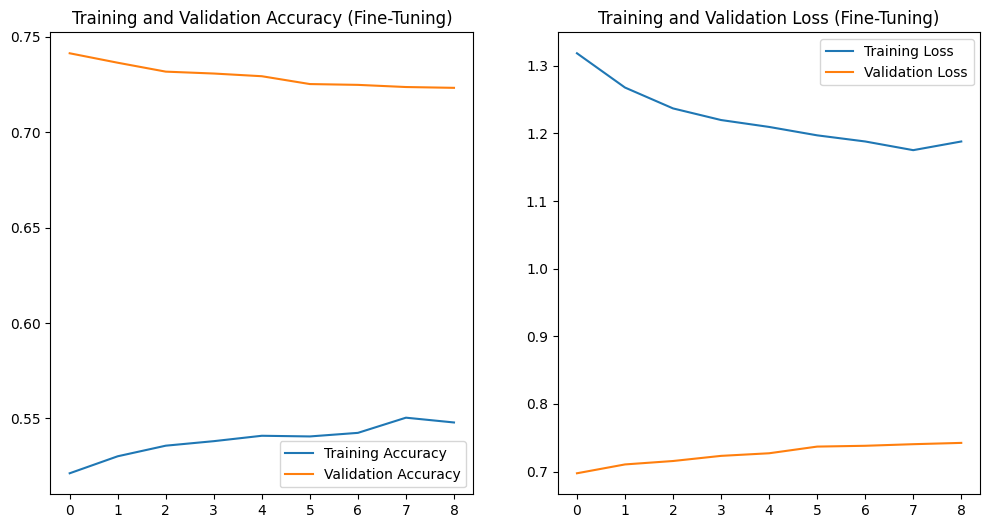

In [5]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Fine-Tuning)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Fine-Tuning)')

os.makedirs('reports', exist_ok=True)
plt.savefig('reports/finetune_history.png')
plt.show()